In [1]:
import pandas as pd
from micom.workflows import load_results, GrowthResults
from micom.measures import production_rates
from skbio.diversity import beta_diversity
from itertools import product
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.patches import Rectangle

%matplotlib inline

In [2]:
res_simulated = load_results('../goll_et.al_2020_IBS_FMT/models_simulated/res_western_simulated.zip')
res_actual = load_results('../goll_et.al_2020_IBS_FMT/models/res_western.zip')

DonorRecipientMapping = pd.read_csv('../goll_et.al_2020_IBS_FMT/raw/DonorRecipientMapping.csv')[['recipient', 'donor', 'clinical_response']]
DonorRecipientMapping['donor'] = DonorRecipientMapping['donor'].str.split('_').str[0]
DonorRecipientMapping['recipient'] = DonorRecipientMapping['recipient'].str.split('_').str[0].str.replace('-0', '')
DonorRecipientMapping['comparison'] = DonorRecipientMapping.apply(lambda x: x['donor'] + '_vs_' + x['recipient'] + '-0', axis=1)

abundance_actual = (
    res_actual.growth_rates[['sample_id', 'taxon', 'abundance']]
    .query('sample_id.str.contains("D") | sample_id.str.endswith("-6")')
    .assign(
        sample_id=lambda x: np.where(
            ~x['sample_id'].str.startswith('D'),
            x['sample_id'].str.replace('-6', ''),
            x['sample_id']
        )
    )
    .merge(
        DonorRecipientMapping[['recipient', 'donor']],
        left_on='sample_id',
        right_on='recipient',
        how='left'
    )
    .assign(
        comparison=lambda x: np.where(
            x['recipient'].isna(),
            x['sample_id'],  # Donor samples
            x['donor'] + '_vs_' + x['recipient'] + '-0'  # Recipient samples
        )
    )
    .pivot_table(index='taxon', columns='comparison', values='abundance', fill_value=0.0)
)

abundance_actual_donors = abundance_actual.loc[:, ~abundance_actual.columns.str.endswith('-0')]
abundance_actual_recipients = abundance_actual.loc[:, abundance_actual.columns.str.endswith('-0')]

abundance_calculated = (
    res_simulated.growth_rates[['sample_id', 'taxon', 'abundance']]
    .query('~sample_id.isin(@abundance_actual_recipients.columns)')
    .pivot_table(index='taxon', columns='sample_id', values='abundance', fill_value=0.0)
)

abundance_all = pd.concat([abundance_actual_donors, abundance_actual_recipients, abundance_calculated], axis=1).fillna(0)
b = beta_diversity(metric='braycurtis', counts=abundance_all.T.values)
distMatrix = pd.DataFrame(b.data, index=abundance_all.T.index, columns=abundance_all.T.index)
donors = abundance_actual_donors.columns.tolist()
T6Recipients = list(set(abundance_all.columns) - set(abundance_actual_donors.columns))
bray_curtis_dissimilarity = {
    'score': [],
    'donor': [],
    'recipient': []
}

for pairs in product(donors, T6Recipients):
    donor_1 = pairs[0]
    donor_2, recipient = pairs[1].split('_vs_')[0], pairs[1].split('_vs_')[1]
    recipient = recipient.replace('-0', '')
    if donor_1 == donor_2:
        score = distMatrix.loc[pairs[0], pairs[1]]
        bray_curtis_dissimilarity['score'].append(score)
        bray_curtis_dissimilarity['donor'].append(donor_1)
        bray_curtis_dissimilarity['recipient'].append(recipient)

bray_curtis_dissimilarity_table = (
    pd.DataFrame(bray_curtis_dissimilarity)
    .pivot_table(
        index='donor',
        columns='recipient',
        values='score',
        fill_value=0.0
    )
    .transpose()
)

# sort donors and recipients
donor_order = bray_curtis_dissimilarity_table.columns.tolist()
recipient_order = bray_curtis_dissimilarity_table.index.tolist()
bray_curtis_dissimilarity_table = bray_curtis_dissimilarity_table.loc[recipient_order, donor_order]

bray_curtis_dissimilarity = (
    pd.DataFrame(bray_curtis_dissimilarity)
    .merge(DonorRecipientMapping[['recipient', 'clinical_response']], on=['recipient'], how='left')
)
bray_curtis_dissimilarity['clinical_response'] = pd.Categorical(bray_curtis_dissimilarity['clinical_response'], ['responder', 'non-responder'], ordered=True)

# baseline t0
abundance_base = (
    res_actual.growth_rates[['sample_id', 'taxon', 'abundance']]
    .query('sample_id.str.endswith("-0") | sample_id.str.contains("D")')
    .pivot_table(index='taxon', columns='sample_id', values='abundance', fill_value=0.0)
)

b_base = beta_diversity(metric='braycurtis', counts=abundance_base.T.values)
distMatrix_base = pd.DataFrame(b_base.data, index=abundance_base.T.index, columns=abundance_base.T.index)
donors = abundance_base.columns[abundance_base.columns.str.contains('D')].tolist()
recipients = abundance_base.columns[abundance_base.columns.str.endswith('-0')].tolist()
bray_curtis_dissimilarity_base = {
    'score': [],
    'donor': [],
    'recipient': []
}
donors = abundance_base.columns[abundance_base.columns.str.contains('D')].tolist()
recipients = abundance_base.columns[abundance_base.columns.str.endswith('-0')].tolist()
for pairs in product(donors, recipients):
    bray_curtis_dissimilarity_base['score'].append(distMatrix_base.loc[pairs[0], pairs[1]])
    bray_curtis_dissimilarity_base['donor'].append(pairs[0])
    bray_curtis_dissimilarity_base['recipient'].append(pairs[1].replace('-0', ''))

bray_curtis_dissimilarity_base_table = (
    pd.DataFrame(bray_curtis_dissimilarity_base)
    .pivot_table(
        index='donor',
        columns='recipient',
        values='score',
        fill_value=0.0
    )
    .transpose()
)

# sort donors and recipients
bray_curtis_dissimilarity_base_table = bray_curtis_dissimilarity_base_table.loc[recipient_order, donor_order]

delta_bray_curtis = (bray_curtis_dissimilarity_base_table - bray_curtis_dissimilarity_table) / bray_curtis_dissimilarity_base_table # relative change
delta_bray_curtis

/home/zetian/.conda/envs/qiime2/lib/python3.9/site-packages/micom/workflows/results.py:55: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  tab = pd.read_csv(zippy.open(f"{attr}.csv", "r"))
/home/zetian/.conda/envs/qiime2/lib/python3.9/site-packages/micom/workflows/results.py:55: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  tab = pd.read_csv(zippy.open(f"{attr}.csv", "r"))


donor,D-10,D-12,D-13U,D-14,D-15Fryst,D-2,D-3,D-4,D-5Fryst,D-6Fresk,D-7Fryst,D-9Fryst
recipient,,,,,,,,,,,,
11,0.310582,0.170435,0.222397,0.317544,0.151916,0.086339,0.147140,0.221058,0.220721,0.226818,0.202498,0.452035
12,0.065611,0.025035,0.073706,0.071482,-0.049915,-0.279936,0.027594,-0.043786,-0.045906,0.053338,-0.061556,0.054470
16,0.447970,0.145483,0.276141,0.245960,0.356870,0.127996,0.437106,0.186670,0.189285,0.269443,0.125416,0.376403
18,0.320637,0.192192,0.255991,0.206686,0.296718,0.121091,0.242721,0.123779,0.108589,0.234019,-0.139954,0.218166
19,0.266747,0.035576,0.174360,0.283737,0.056160,0.151798,0.376441,0.251148,0.243505,0.314212,0.061688,0.335133
22,0.238402,0.171637,0.228143,0.276099,0.320673,0.214944,0.149336,0.225454,0.228597,0.264698,0.221752,0.290095
23,0.105081,0.059281,0.112638,0.256227,0.014695,0.051565,-0.056215,0.074232,0.054817,0.106488,0.070811,0.154312
24,0.180609,0.030713,0.197650,0.093025,0.273271,-0.058927,0.100843,-0.106785,-0.048730,0.058701,-0.094976,0.103961
25,0.048336,-0.118873,-0.037154,0.095123,0.135658,0.008576,-0.013145,-0.007492,-0.084898,-0.021602,-0.047178,0.003527


Pair not found in data: 3-D-1


Text(0.5, 0.98, 'Bray Curtis Dissimilarity of Engraftment Rate of All Pairs of Donor and IBS Patient')

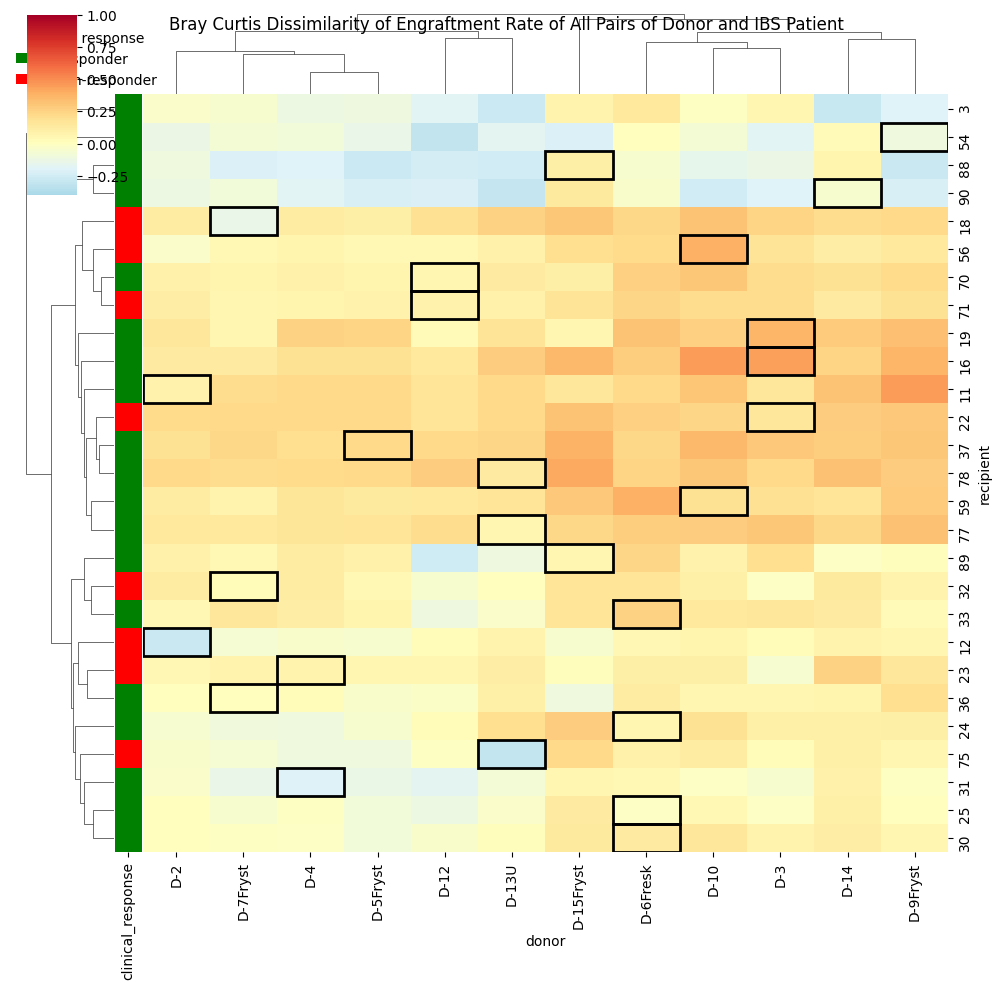

In [3]:
response_colors = DonorRecipientMapping[['recipient', 'clinical_response']].set_index('recipient')['clinical_response'].map(
    {
        'responder': 'green',
        'non-responder': 'red'
    }
)
response_paired = {v: k for k, v in zip(DonorRecipientMapping['donor'], DonorRecipientMapping['recipient'])}

g = sns.clustermap(
    data=delta_bray_curtis,
    figsize=(10,10),
    row_colors=response_colors,
    col_cluster=True,
    row_cluster=True,
    cmap='RdYlBu_r',
    center=0.0,
    vmin=-0.4, vmax=1.0,
    dendrogram_ratio=(0.1, 0.1),
    cbar_pos=(0.02, 0.8, 0.05, 0.18)
)

for recipient, donor in response_paired.items():
    try:
        # Find positions after clustering
        row_idx = np.where(g.data2d.index == recipient)[0][0]
        col_idx = np.where(g.data2d.columns == donor)[0][0]
        
        # Add red rectangle
        rect = Rectangle(
            (col_idx, row_idx),
            1, 1,
            fill=False,
            edgecolor='black',
            linewidth=2,
            linestyle='-'
        )
        g.ax_heatmap.add_patch(rect)
    except IndexError:
        print(f"Pair not found in data: {recipient}-{donor}")

legend_elements = [
    plt.Rectangle((0,0),1,1, fc='green', label='Responder'),
    plt.Rectangle((0,0),1,1, fc='red', label='Non-responder'),
]

g.ax_row_dendrogram.legend(
    handles=legend_elements,
    title='clinical response',
    bbox_to_anchor=(1.6, 1.1),
    frameon=False
)

plt.suptitle("Bray Curtis Dissimilarity of Engraftment Rate of All Pairs of Donor and IBS Patient")

In [17]:
simulated_res = load_results('../goll_et.al_2020_IBS_FMT/openbiome_simulated_models/res_western_simulated_openbiome.zip')
simulated_growth = simulated_res.growth_rates.copy()
donors = [os.path.basename(d.replace('.pickle', '')) for d in os.listdir('../goll_et.al_2020_IBS_FMT/openbiome_models/') if d.endswith('.pickle')]
recipients = simulated_growth['sample_id'].unique()

abundance_openbiome_simulated = (
    simulated_growth[['sample_id', 'taxon', 'abundance']]
    .pivot_table(index='taxon', columns='sample_id', values='abundance', fill_value=0.0)
)

abundance_openbiome_donors = (
    load_results('../goll_et.al_2020_IBS_FMT/openbiome_models/res_western_openbiome.zip')
    .growth_rates[['sample_id', 'taxon', 'abundance']]
    .pivot_table(index='taxon', columns='sample_id', values='abundance', fill_value=0.0)
)

abundance_all_openbiome = pd.concat([abundance_openbiome_donors, abundance_openbiome_simulated], axis=1).fillna(0)
b = beta_diversity(metric='braycurtis', counts=abundance_all_openbiome.T.values)
distMatrix = pd.DataFrame(b.data, index=abundance_all_openbiome.T.index, columns=abundance_all_openbiome.T.index)
bray_curtis_dissimilarity_openbiome = {
    'score': [],
    'donor': [],
    'recipient': []
}

for pairs in product(donors, recipients):
    donor_1 = pairs[0]
    donor_2, recipient = pairs[1].split('_vs_')[0], pairs[1].split('_vs_')[1]
    recipient = recipient.replace('-0', '')
    if donor_1 == donor_2:
        score = distMatrix.loc[pairs[0], pairs[1]]
        bray_curtis_dissimilarity_openbiome['score'].append(score)
        bray_curtis_dissimilarity_openbiome['donor'].append(donor_1)
        bray_curtis_dissimilarity_openbiome['recipient'].append(recipient)

recipients = [r.replace('-0', '') for r in simulated_growth['sample_id'].str.split('_vs_').str[1].unique()]

bray_curtis_dissimilarity_openbiome_table = (
    pd.DataFrame(bray_curtis_dissimilarity_openbiome)
    .pivot_table(
        index='donor',
        columns='recipient',
        values='score',
        fill_value=0.0
    )
    .transpose()
    .loc[recipients, donors]
)

# baseline t0 extracted from original abundance dataframe
abundance_original_recipient_base = (
    abundance_base.loc[:, abundance_base.columns.str.endswith('-0')]
    .assign(
        **{col.replace('-0', ''): abundance_base[col] for col in abundance_base.columns if col.endswith('-0')}
    )
)
abundance_openbiome_base = pd.concat([abundance_openbiome_donors, abundance_original_recipient_base], axis=1).fillna(0)
b_base = beta_diversity(metric='braycurtis', counts=abundance_openbiome_base.T.values)
distMatrix_base = pd.DataFrame(b_base.data, index=abundance_openbiome_base.T.index, columns=abundance_openbiome_base.T.index)
bray_curtis_dissimilarity_openbiome_base = {
    'score': [],
    'donor': [],
    'recipient': []
}
for pairs in product(donors, recipients):
    bray_curtis_dissimilarity_openbiome_base['score'].append(distMatrix_base.loc[pairs[0], pairs[1]])
    bray_curtis_dissimilarity_openbiome_base['donor'].append(pairs[0])
    bray_curtis_dissimilarity_openbiome_base['recipient'].append(pairs[1])

bray_curtis_dissimilarity_openbiome_base_table = (
    pd.DataFrame(bray_curtis_dissimilarity_openbiome_base)
    .pivot_table(
        index='donor',
        columns='recipient',
        values='score',
        fill_value=0.0
    )
    .transpose()
    .loc[recipients, donors]
)

delta_bray_curtis_openbiome = (bray_curtis_dissimilarity_openbiome_base_table - bray_curtis_dissimilarity_openbiome_table) / bray_curtis_dissimilarity_openbiome_base_table # relative change
delta_bray_curtis_openbiome

/home/zetian/.conda/envs/qiime2/lib/python3.9/site-packages/micom/workflows/results.py:55: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  tab = pd.read_csv(zippy.open(f"{attr}.csv", "r"))
/home/zetian/.conda/envs/qiime2/lib/python3.9/site-packages/micom/workflows/results.py:55: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  tab = pd.read_csv(zippy.open(f"{attr}.csv", "r"))


donor,SRR9224051,SRR9224546,SRR9224439,SRR9224059,SRR9224377,SRR9224190,SRR9224548,SRR9224030,SRR9224132,SRR9224466,...,SRR9224409,SRR9224464,SRR9224543,SRR9224443,SRR9224040,SRR9224381,SRR9224383,SRR9224555,SRR9224150,SRR9224152
recipient,,,,,,,,,,,,,,,,,,,,,
88,-0.215118,0.011798,-0.262459,0.165110,-0.198862,-0.198425,0.001115,-0.019787,-0.021820,0.005849,...,0.001902,0.183036,-0.072907,-0.024651,-0.034271,0.294581,0.352231,0.039904,0.003209,0.101169
75,0.148451,0.047793,0.128677,0.135363,0.122578,0.105683,0.018281,0.133136,0.113399,0.072534,...,0.142162,0.142116,0.093067,0.212412,0.127064,0.303839,0.331375,0.164859,0.177376,0.067982
3,-0.000437,0.035422,-0.023786,0.094285,-0.027855,-0.039709,0.032069,0.024616,0.050368,0.036280,...,0.064637,0.202260,-0.063070,0.252439,0.011815,0.255854,0.383405,0.037952,0.017473,0.236840
32,0.272045,0.074378,0.199754,0.311696,0.246623,0.261315,0.065696,0.345855,0.262873,0.121710,...,0.257535,0.285136,0.204882,0.142023,0.200318,0.348486,0.258514,0.282519,0.195841,0.246297
64,0.090745,0.022662,0.224629,0.123803,0.177026,0.134051,0.041162,0.136601,0.077896,0.057954,...,0.197291,0.232101,0.170188,0.087693,0.139016,0.137099,0.091430,0.192679,0.187708,0.113693
66,-0.016504,0.046115,0.006646,0.135180,0.074577,0.018263,0.031662,0.017880,0.020104,0.042990,...,0.036214,0.193627,0.085226,0.274019,0.017638,0.360402,0.318393,0.258444,0.077233,0.037373
25,0.005867,0.029432,-0.022255,0.140700,-0.032176,0.047953,0.029739,0.041466,0.074450,0.055166,...,0.150575,0.180174,0.087749,0.126778,0.095595,0.230052,0.426036,0.145215,0.097778,0.125048
24,0.053713,0.065631,0.030884,0.153121,0.041308,0.079239,0.035098,0.007340,0.034786,0.081804,...,0.052892,0.227634,0.063563,0.266438,0.050593,0.309596,0.413747,0.312263,0.180697,0.084186
19,0.166788,0.055230,0.172248,0.141025,0.173998,0.184226,0.045909,0.182222,0.152305,0.097078,...,0.316687,0.387504,0.330531,0.348437,0.184365,0.159017,0.320110,0.361365,0.345708,0.254860


In [18]:
delta_bray_curtis_combined = pd.concat([delta_bray_curtis, delta_bray_curtis_openbiome], axis=1).dropna(axis=0)
delta_bray_curtis_combined

donor,D-10,D-12,D-13U,D-14,D-15Fryst,D-2,D-3,D-4,D-5Fryst,D-6Fresk,...,SRR9224409,SRR9224464,SRR9224543,SRR9224443,SRR9224040,SRR9224381,SRR9224383,SRR9224555,SRR9224150,SRR9224152
recipient,,,,,,,,,,,,,,,,,,,,,
11,0.310582,0.170435,0.222397,0.317544,0.151916,0.086339,0.147140,0.221058,0.220721,0.226818,...,0.325751,0.321426,0.309252,0.170358,0.237064,0.294579,0.280348,0.287272,0.359723,0.109622
12,0.065611,0.025035,0.073706,0.071482,-0.049915,-0.279936,0.027594,-0.043786,-0.045906,0.053338,...,0.135433,0.164296,0.097760,0.179462,0.143924,0.210657,0.293625,0.179002,0.073413,0.029606
16,0.447970,0.145483,0.276141,0.245960,0.356870,0.127996,0.437106,0.186670,0.189285,0.269443,...,0.260139,0.260451,0.214123,0.311058,0.183629,0.319143,0.283204,0.354266,0.276125,0.128409
18,0.320637,0.192192,0.255991,0.206686,0.296718,0.121091,0.242721,0.123779,0.108589,0.234019,...,0.208788,0.241327,0.208659,0.302621,0.129156,0.365209,0.449607,0.321953,0.233520,0.160168
19,0.266747,0.035576,0.174360,0.283737,0.056160,0.151798,0.376441,0.251148,0.243505,0.314212,...,0.316687,0.387504,0.330531,0.348437,0.184365,0.159017,0.320110,0.361365,0.345708,0.254860
22,0.238402,0.171637,0.228143,0.276099,0.320673,0.214944,0.149336,0.225454,0.228597,0.264698,...,0.312021,0.241317,0.333352,0.328644,0.360532,0.273940,0.336036,0.321797,0.337265,0.257560
23,0.105081,0.059281,0.112638,0.256227,0.014695,0.051565,-0.056215,0.074232,0.054817,0.106488,...,0.257064,0.219272,0.248229,0.236822,0.199257,0.331700,0.272112,0.316588,0.265056,0.148249
24,0.180609,0.030713,0.197650,0.093025,0.273271,-0.058927,0.100843,-0.106785,-0.048730,0.058701,...,0.052892,0.227634,0.063563,0.266438,0.050593,0.309596,0.413747,0.312263,0.180697,0.084186
25,0.048336,-0.118873,-0.037154,0.095123,0.135658,0.008576,-0.013145,-0.007492,-0.084898,-0.021602,...,0.150575,0.180174,0.087749,0.126778,0.095595,0.230052,0.426036,0.145215,0.097778,0.125048


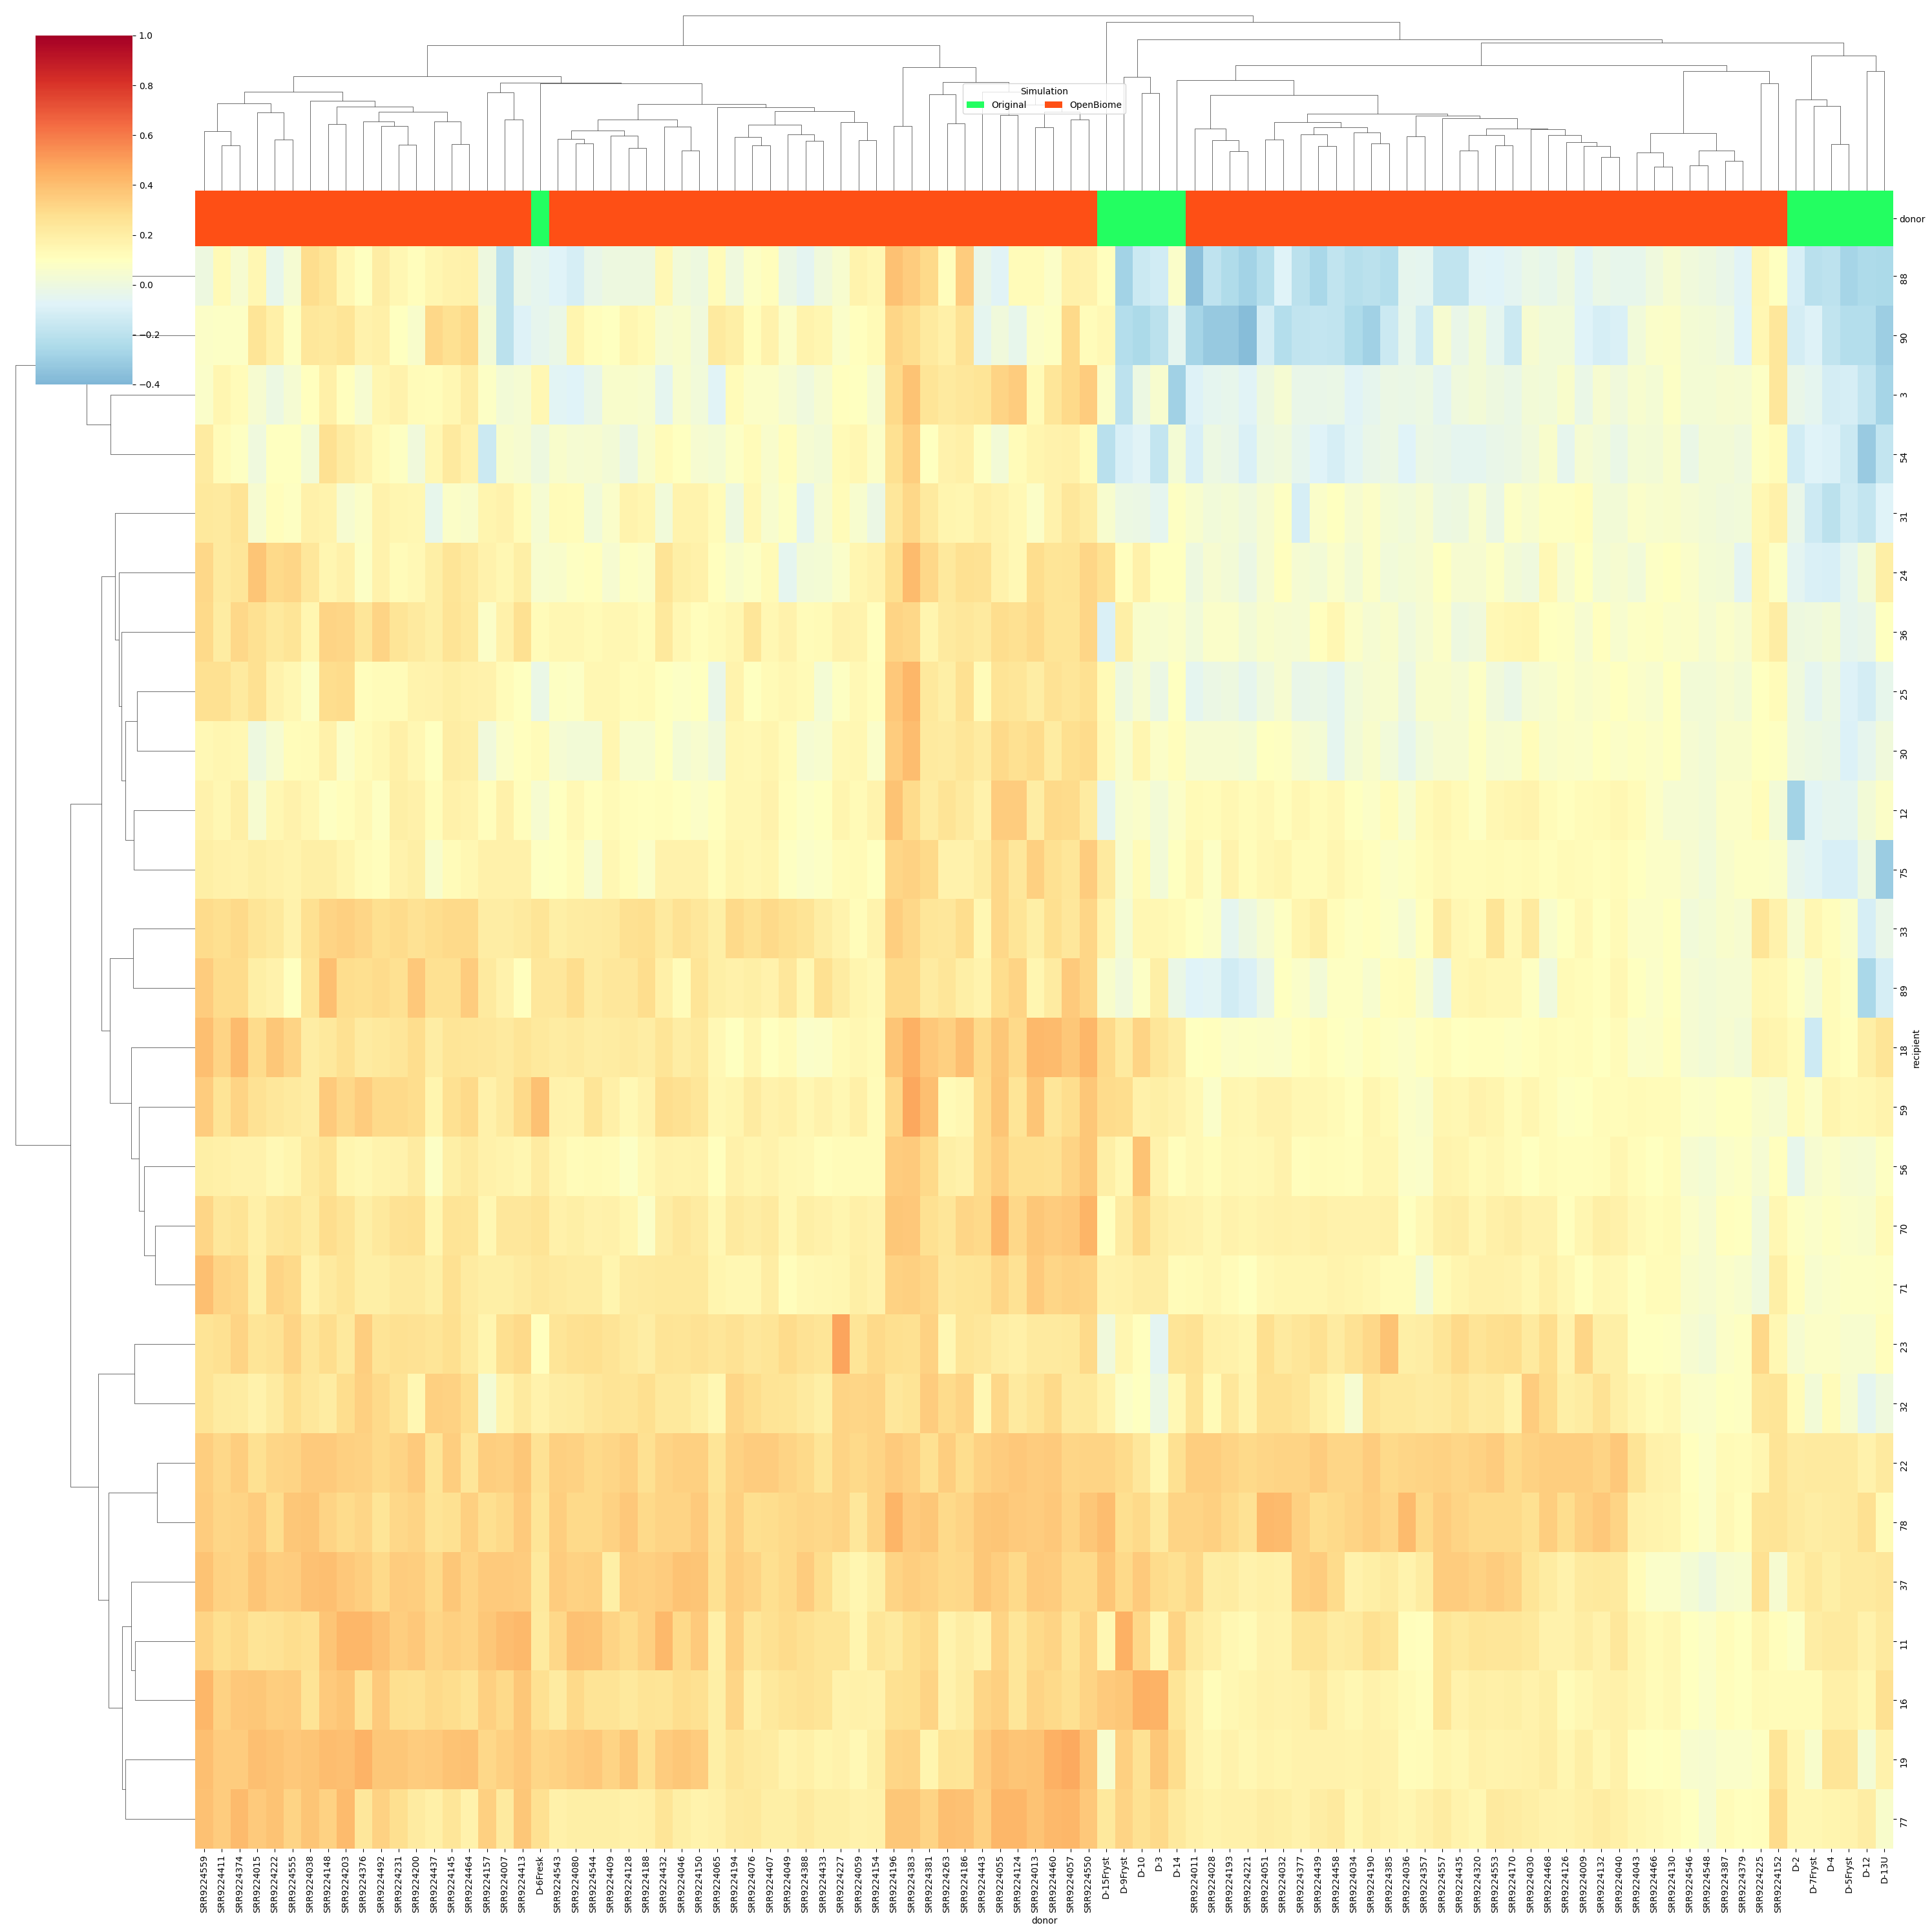

In [19]:
labels = pd.Series(delta_bray_curtis_combined.columns, index=delta_bray_curtis_combined.columns).map(
    lambda x: 'Original' if str(x).startswith('D') else 'OpenBiome'
)
palette = {'Original': "#23fe61", 'OpenBiome': "#fe4f15"}
col_colors = labels.map(palette)
g = sns.clustermap(
    data=delta_bray_curtis_combined,
    figsize=(30, 30),
    col_colors=col_colors,
    col_cluster=True,
    row_cluster=True,
    cmap='RdYlBu_r',
    center=0.1,
    vmin=-0.4, 
    vmax=1,
    dendrogram_ratio=(0.1, 0.1),
    cbar_pos=(0.02, 0.8, 0.05, 0.18)
)
handles = [Patch(facecolor=palette[k], label=k) for k in palette]
g.ax_col_dendrogram.legend(handles=handles, title="Simulation", loc="center", ncol=2)

In [22]:
# pick a recipient, plot all donor engraftment vs scfa flux
scfa = {
    'propionate': 'ppa[e]', 
    'acetate': 'ac[e]', 
    'butyrate': 'but[e]', 
    'Formate': 'for[e]', 
}

gas = {
    'Hydrogen': 'h2[e]', 
    'Methanethiol': 'ch4s[e]'
}

sulfur = {
    'Sulfite': 'so3[e]', 
    'thiosulfate(2-)': 'tsul[e]', 
}

# combine all metabolites to plot
metabolites_to_plot = {**scfa, **gas, **sulfur}

DonorRecipientPairing = {v: k for k, v in zip(DonorRecipientMapping['donor'], DonorRecipientMapping['recipient'])}

simulated_exchanges = simulated_res.exchanges.copy()
simulated_exchanges = (
    simulated_exchanges
    .query('metabolite.isin(@metabolites_to_plot.values())')
    .query('taxon != "medium" and direction == "export"')
    .assign(flux=lambda x: x['flux'] * x['abundance'])
    .groupby(['sample_id', 'metabolite'], as_index=False)
    .agg({'flux': 'sum'})
    .assign(donor=lambda x: x['sample_id'].str.split('_vs_').str[0])
    .assign(recipient=lambda x: x['sample_id'].str.split('_vs_').str[1].str.replace('-0', ''))
    .merge(
        delta_bray_curtis_openbiome.reset_index().melt(id_vars='recipient', var_name='donor', value_name='engraftment rate'),
        on=['donor', 'recipient'],
        how='inner')
    .drop(columns=['sample_id'])
)

# find the calculated exchanges for the actual donors and recipients, replace actual donor recipient pairing with t6 data
exchanges_calculated = (
    res_simulated.exchanges.copy()
    .query('metabolite.isin(@metabolites_to_plot.values())')
    .query('taxon != "medium" and direction == "export"')
    .assign(flux=lambda x: x['flux'] * x['abundance'])
    .groupby(['sample_id', 'metabolite'], as_index=False)
    .agg({'flux': 'sum'})
    .assign(donor=lambda x: x['sample_id'].str.split('_vs_').str[0])
    .assign(recipient=lambda x: x['sample_id'].str.split('_vs_').str[1].str.replace('-0', ''))
    .merge(
        delta_bray_curtis.reset_index().melt(id_vars='recipient', var_name='donor', value_name='engraftment rate'),
        on=['donor', 'recipient'],
        how='inner'
    )
    .drop(columns=['sample_id'])
    .loc[lambda df: ~df.apply(lambda row: DonorRecipientPairing.get(row['recipient']) == row['donor'], axis=1)]
)

exchanges_actual = (
    res_actual.exchanges.copy()
    .query('metabolite.isin(@metabolites_to_plot.values())')
    .query('taxon != "medium" and direction == "export"')
    .query('sample_id.str.endswith("-6")')
    .assign(flux=lambda x: x['flux'] * x['abundance'])
    .groupby(['sample_id', 'metabolite'], as_index=False)
    .agg({'flux': 'sum'})
    .assign(recipient=lambda x: x['sample_id'].str.replace('-6', ''))
    .assign(donor=lambda x: x['recipient'].map(DonorRecipientPairing))
    .drop(columns=['sample_id'])
)

exchanges_combined = pd.concat([exchanges_calculated, exchanges_actual], axis=0)
exchanges_combined_scfa = (
    exchanges_combined
    .query('metabolite.isin(@scfa.values())')
    .groupby(['donor', 'recipient', 'engraftment rate'], as_index=False)
    .agg({'flux': 'sum'})
    .assign(metabolism='scfa metabolism')
)

exchanges_combined_gas = (
    exchanges_combined
    .query('metabolite.isin(@gas.values())')
    .groupby(['donor', 'recipient', 'engraftment rate'], as_index=False)
    .agg({'flux': 'sum'})
    .assign(metabolism='gas metabolism')
)

exchanges_combined_sulfur = (
    exchanges_combined
    .query('metabolite.isin(@sulfur.values())')
    .groupby(['donor', 'recipient', 'engraftment rate'], as_index=False)
    .agg({'flux': 'sum'})
    .assign(metabolism='sulfur metabolism')
)

exchanges_combined_reduced = pd.concat([exchanges_combined_scfa, exchanges_combined_gas, exchanges_combined_sulfur], axis=0)
exchanges_combined_reduced

,donor,recipient,engraftment rate,flux,metabolism
0,D-10,11,0.310582,4.190407e+01,scfa metabolism
1,D-10,12,0.065611,3.864760e+01,scfa metabolism
2,D-10,16,0.447970,3.179354e+01,scfa metabolism
3,D-10,18,0.320637,3.610254e+01,scfa metabolism
4,D-10,19,0.266747,3.677852e+01,scfa metabolism
...,...,...,...,...,...
237,D-7Fryst,59,0.073871,2.888304e-08,sulfur metabolism
238,D-7Fryst,70,0.066170,3.237736e-09,sulfur metabolism
239,D-7Fryst,77,0.144172,1.874750e-09,sulfur metabolism
240,D-7Fryst,89,0.042951,6.257786e-09,sulfur metabolism


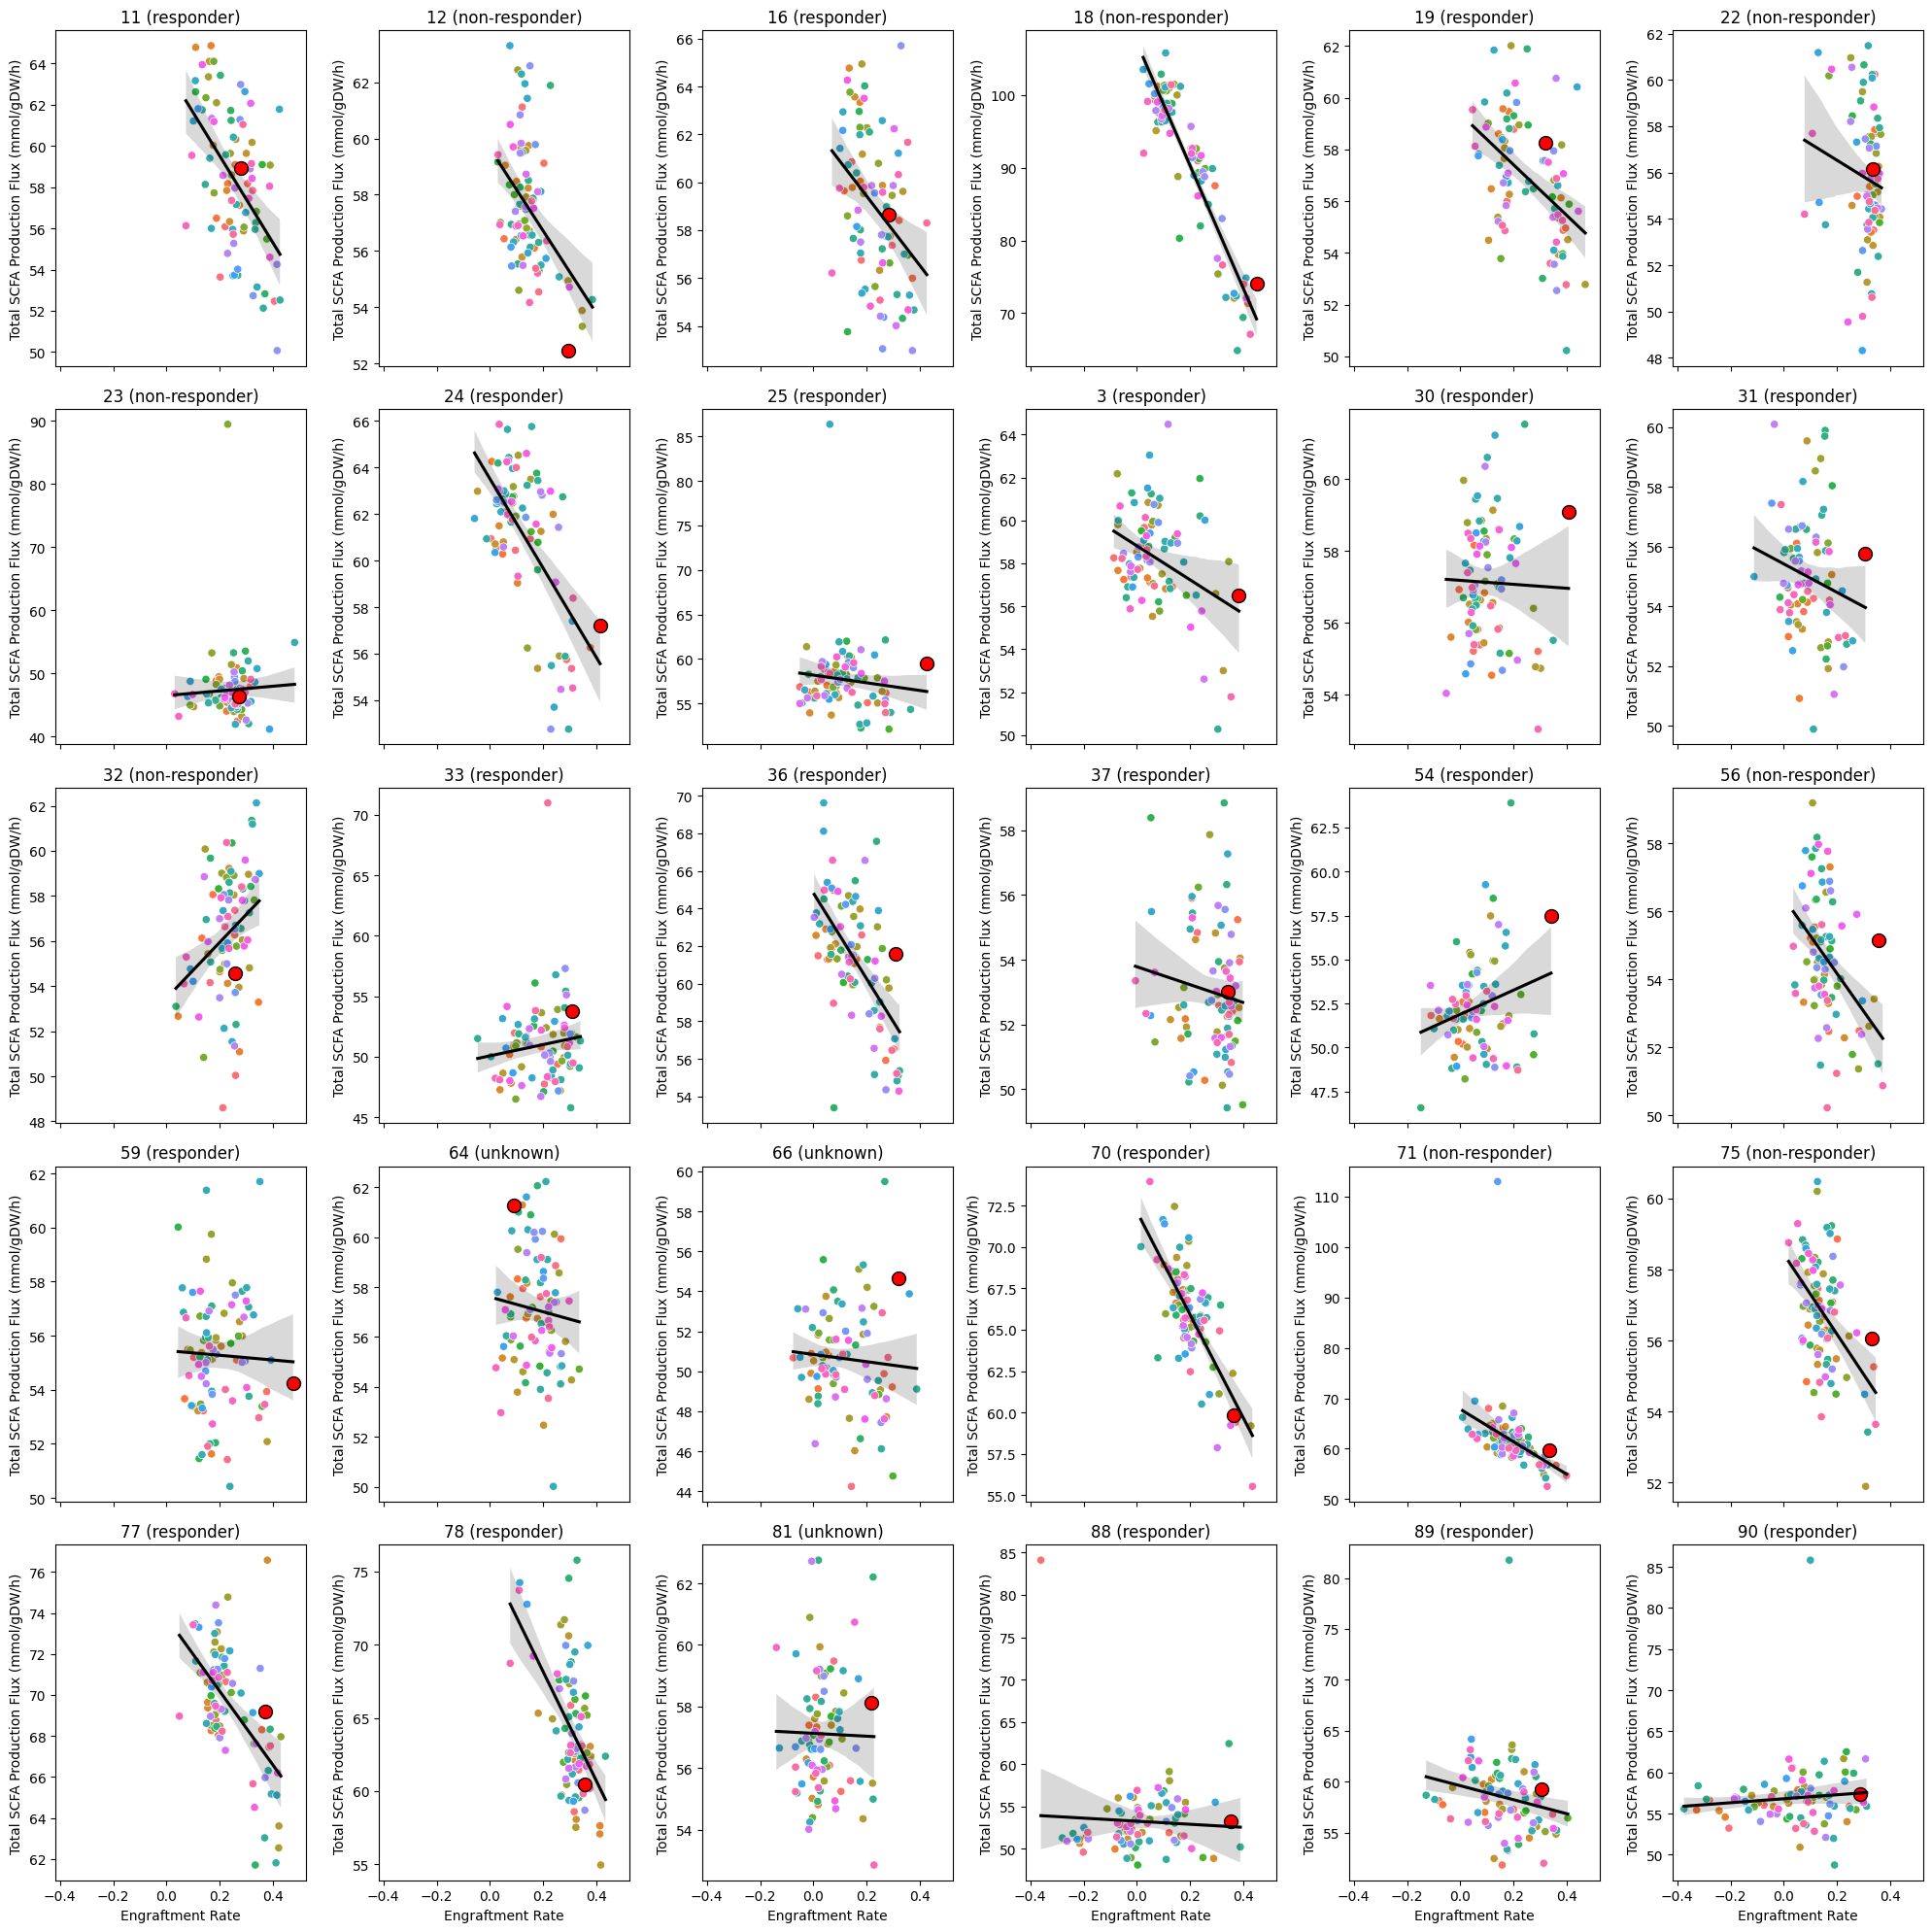

In [ ]:
f, axes = plt.subplots(5, 6, figsize=(20, 20))
# find the donor that has the average highest engraftment rate across all recipients
avg_engraftment = simulated_exchanges.groupby('donor')['engraftment rate'].mean()
super_donor = avg_engraftment.idxmax()
clinical_response = {k: v for k, v in zip(DonorRecipientMapping['recipient'], DonorRecipientMapping['clinical_response'])}

axes = axes.flatten()
for i, recipient in enumerate(simulated_exchanges['recipient'].unique()):
    df_plot = simulated_exchanges.query('recipient == @recipient')
    sns.scatterplot(
        data=df_plot,
        x='engraftment rate',
        y='flux',
        hue='donor',
        ax=axes[i],
        legend=False
    )
    sns.regplot(
        data=df_plot,
        x='engraftment rate',
        y='flux',
        scatter=False,
        ax=axes[i],
        line_kws={'color': 'black'}
    )

    # label super donor
    x_super = df_plot.query('donor == @super_donor')['engraftment rate'].values
    y_super = df_plot.query('donor == @super_donor')['flux'].values
    axes[i].scatter(x_super, y_super, color='red', s=100, edgecolor='black', label=f'{super_donor}')

    axes[i].set_title(f'{recipient} ({clinical_response.get(recipient, "unknown")})')
    axes[i].set_ylabel('Total SCFA Production Flux (mmol/gDW/h)')
    axes[i].set_xlabel('Engraftment Rate')

plt.tight_layout()